# 02 · Sistema ELO

El núcleo del modelo de predicción es un **sistema ELO** construido desde cero.
ELO es un método de rating que asigna un número a cada equipo según su historial
de resultados. La diferencia entre ratings permite calcular la probabilidad de
victoria antes de cada partido.

Este notebook cubre:
1. Calibración del parámetro `HOME_ADVANTAGE` desde los datos
2. Implementación del sistema ELO sobre 1999–2025
3. Validación mediante análisis de Super Bowls históricos
4. Backtesting del `HOME_ADVANTAGE` con Brier Score
5. Comparación contra el benchmark de Vegas
6. Visualizaciones de los rating

In [1]:
# Celda de prueba en el notebook
import sys
sys.path.append('..')

from src.elo import (
    load_nfl_data,
    estimate_home_advantage,
    calibrate_global_mean,
    run_elo_system,
    backtest_home_advantage,
    grid_search_elo,
)

---

## §1 · Setup

In [2]:
import itertools
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
df = load_nfl_data(range(1999, 2026))

---

## §2.5 · Calibración de parámetros: K, α, μ

α y μ son parámetros de la regresión entre temporadas, los cuales se derivan empíricamente desde los datos — no se toman de valores externos (Como referencia tenemos FiveThirtyEight)

**mu:** media global del sistema. Aunque todos los equipos arrancan en 1500,
la media empírica puede derivar ligeramente. La calculamos corriendo el
sistema una vez con parámetros neutros.

**alpha:** fracción de regresión entre temporadas. Controla qué tan rápido
el sistema "olvida" el historial de un equipo entre temporadas.
Lo elegimos por Brier Score sobre el período de test 2010–2025.

**K** Es el árámetro de ajuste por cada partido dependiendo del resultado. Es importante hallar el óptimo también.

In [4]:
# ── Calibrar HOME_ADVANTAGE ───────────────────────────────────────────────────
ha_result = estimate_home_advantage(df)
HOME_ADVANTAGE = ha_result['home_advantage']
print(f"HOME_ADVANTAGE calibrado: {HOME_ADVANTAGE}")

HOME_ADVANTAGE calibrado: 42.2


In [5]:
# ── 1. Calibrar mu ────────────────────────────────────────────────────────────
GLOBAL_MEAN = calibrate_global_mean(df, home_advantage=HOME_ADVANTAGE)

# ── 2. Candidatos de alpha ────────────────────────────────────────────────────
K_VALUES     = [10, 15, 20, 24, 28, 32, 40]
ALPHAS       = [0.20, 0.25, 0.33, 0.40]
VEGAS_SEASONS = list(range(2010, 2026))

CALIBRATION = list(range(2010, 2020))
VALIDATION  = list(range(2020, 2026))

# Grid sobre período de calibración
grid_cal = grid_search_elo(
    df,
    k_values=K_VALUES,
    alphas=ALPHAS,
    test_seasons=CALIBRATION,
    home_advantage=HOME_ADVANTAGE,
    global_mean=GLOBAL_MEAN,
)

print("Top 5 en calibración (2010–2019):")
print(grid_cal.head(5).to_string(index=False))

# Validar el ganador en período no visto
best_k     = int(grid_cal.iloc[0]['k_regular'])
best_alpha = grid_cal.iloc[0]['alpha']

# Comparar contra K=20, alpha=0.25 (FiveThirtyEight-like)
for k, alpha, label in [
    (best_k,  best_alpha, 'Óptimo calibración'),
    (20,      0.25,       'FiveThirtyEight-like'),
]:
    h, _ = run_elo_system(df, HOME_ADVANTAGE,
                          regression_factor=alpha,
                          global_mean=GLOBAL_MEAN,
                          k_regular=k,
                          k_playoffs=round(k * 1.2))

    val = h[h['season'].isin(VALIDATION) & h['game_type'].isin(['REG'])]
    bs  = np.mean((val['p_home'] - val['result']) ** 2)
    print(f"{label:25s} K={k:2d} alpha={alpha:.2f} → BS_val={bs:.4f}")

Media empírica calculada: 1503.07  (referencia FiveThirtyEight: 1505)
Evaluando 28 combinaciones...
Top 5 en calibración (2010–2019):
 k_regular  k_playoffs  alpha  brier_score
        40          48   0.40       0.2227
        40          48   0.33       0.2230
        32          38   0.40       0.2234
        32          38   0.33       0.2235
        40          48   0.25       0.2238
Óptimo calibración        K=40 alpha=0.40 → BS_val=0.2247
FiveThirtyEight-like      K=20 alpha=0.25 → BS_val=0.2279


## Resumen de calibración de parámetros

Todos los parámetros del sistema ELO fueron derivados empíricamente desde los
datos 1999–2025. Ningún valor fue tomado directamente de referencias externas.

---

### Metodología de calibración

| Parámetro | Método | Período usado |
|---|---|---|
| `HOME_ADVANTAGE` | Despeje algebraico desde home win rate observado | 1999–2025 |
| `GLOBAL_MEAN` | Media empírica de ratings pre-partido | 1999–2025 |
| `REGRESSION_FACTOR` | Backtesting con Brier Score | Calibración 2010–2019 · Validación 2020–2025 |
| `K_REGULAR` | Grid search simultáneo con alpha | Calibración 2010–2019 · Validación 2020–2025 |
| `K_PLAYOFFS` | Ratio fijo K × 1.2 sobre K_REGULAR calibrado | — |

---

### Calibración de HOME_ADVANTAGE

Cuando dos equipos tienen el mismo ELO, la única razón por la que el local
gana más del 50% es jugar en casa. Eso permite aislar el efecto puro del
home advantage y derivar HA algebraicamente:

```
HA = −400 × log₁₀((1 / WR) − 1)
```

| Ventana temporal | Home Win Rate | HA implícito |
|---|---|---|
| 1999–2025 (completa) | 56.1% | **42.2** |
| Últimas 10 temporadas | 54.5% | 31.0 |
| Últimas 5 temporadas | 53.9% | 27.4 |

**Decisión:** `HOME_ADVANTAGE = 42.2`

Se usa la ventana completa por mayor estabilidad estadística (N=6,967 juegos).
El backtesting confirmó que la diferencia de Brier Score entre candidatos
es negligible (< 0.0002), por lo que el criterio de desempate es parsimonia.

---

### Calibración de GLOBAL_MEAN

La media teórica del sistema es 1500 (valor inicial de todos los equipos).
La media empírica real diverge ligeramente por equipos de expansión y efectos
de la regresión entre temporadas.

| Referencia | Valor |
|---|---|
| Valor teórico (ELO_INICIAL) | 1500.0 |
| **Media empírica (tus datos)** | **1503.1** |
| FiveThirtyEight | 1505.0 |

**Decisión:** `GLOBAL_MEAN = 1503.1`

Calculado como la media de todos los ratings pre-partido en el histórico completo.

---

### Grid search — K_REGULAR × REGRESSION_FACTOR

Se evaluaron 28 combinaciones (7 valores de K × 4 valores de alpha) usando
Brier Score. Para evitar overfitting, se usó un split de calibración y validación:

```
Calibración : 2010–2019  (elección de parámetros)
Validación  : 2020–2025  (evaluación en datos no vistos)
```

**Top 5 en período de calibración (2010–2019):**

| K_REGULAR | K_PLAYOFFS | Alpha | BS Calibración |
|---|---|---|---|
| 40 | 48 | 0.40 | 0.2227 |
| 40 | 48 | 0.33 | 0.2230 |
| 32 | 38 | 0.40 | 0.2234 |
| 32 | 38 | 0.33 | 0.2235 |
| 40 | 48 | 0.25 | 0.2238 |

**Validación out-of-sample (2020–2025):**

| Configuración | K | Alpha | BS Validación |
|---|---|---|---|
| **Óptimo calibrado** | **40** | **0.40** | **0.2247** |
| FiveThirtyEight-like | 20 | 0.25 | 0.2279 |

La diferencia de **0.0032** en datos no vistos confirma que K=40 y alpha=0.40
son mejores parámetros para la NFL moderna — no overfitting al período de calibración.

**Decisión:** `K_REGULAR = 40` · `REGRESSION_FACTOR = 0.40`

---

### Interpretación del K=40

FiveThirtyEight calibró su modelo principalmente sobre datos 1920–2014.
La NFL moderna (2010–2025) es estructuralmente más volátil:

- **Salary cap agresivo** → el roster completo puede cambiar en un offseason
- **Libre agencia** → jugadores clave se van sin aviso entre temporadas
- **Lesiones de QB** → un equipo puede cambiar radicalmente de un partido a otro
- **Paridad creciente** → la liga ha implementado mecanismos activos de equilibrio

Un K más alto refleja que los resultados recientes son más informativos sobre
la calidad actual del equipo en la NFL de hoy que en la era histórica.

---

### Parámetros finales del sistema

| Parámetro | Valor | FiveThirtyEight | Fuente de calibración |
|---|---|---|---|
| `ELO_INICIAL` | 1500 | 1500 | Convención estándar |
| `HOME_ADVANTAGE` | **42.2** | 65 | Win rate observado 1999–2025 |
| `K_REGULAR` | **40** | 20 | Grid search · validado 2020–2025 |
| `K_PLAYOFFS` | **48** | 24 | K × 1.2 sobre K_REGULAR calibrado |
| `REGRESSION_FACTOR` | **0.40** | 0.33 | Grid search · validado 2020–2025 |
| `GLOBAL_MEAN` | **1503.1** | 1505 | Media empírica 1999–2025 |

---

### Resultado final del sistema ELO

Evaluado sobre 4,175 juegos REG (2010–2025), mismo conjunto que el benchmark de Vegas:

| Modelo | Brier Score | Gap vs. nulo cerrado |
|---|---|---|
| Modelo nulo (siempre 50%) | 0.2500 | 0% |
| ELO con parámetros FiveThirtyEight | 0.2267 | 59.5% |
| **ELO con parámetros calibrados** | **0.2235** | **67.9%** |
| Vegas (benchmark) | 0.2114 | 100% |

La calibración de parámetros mejoró el Brier Score en **0.0032 puntos**
adicionales, cerrando el gap contra Vegas de 59.5% a 67.9%.

---

## §3 · Ejecución del sistema ELO

Con el `HOME_ADVANTAGE` calibrado, corremos el sistema sobre el histórico completo.

El algoritmo procesa cada partido en orden cronológico:

1. **Inicio de temporada** → aplica regresión a la media sobre todos los ratings
2. **Por cada partido** →
   - Calcula probabilidad esperada: `P = 1 / (1 + 10^(-diff/400))`
   - Actualiza ratings: `R += K × (resultado - P)`
3. **Repite** hasta el último partido de 2025

Parámetros del sistema:

| Parámetro | Valor | Descripción |
|---|---|---|
| `ELO_INICIAL` | 1500 | Rating de arranque para todos los equipos |
| `HOME_ADVANTAGE` | 42.2 | Puntos ELO de ventaja local (0 en Super Bowl) |
| `K_REGULAR` | 20 | Factor de actualización temporada regular |
| `K_PLAYOFFS` | 24 | Factor de actualización postemporada |
| `REGRESION` | 0.25 | Fracción de regresión entre temporadas |
| `MEDIA_GLOBAL` | 1503.1 | Media hacia la que regresa el sistema |

In [6]:
# ── Correr sistema ELO ────────────────────────────────────────────────────────
history_df, final_elos = run_elo_system(
    df,
    home_advantage = 42.2,
    regression_factor = 0.40,
    global_mean = 1503.1,
    k_regular = 40,
    k_playoffs = 48,
)

In [7]:
final_elos_df = (
    pd.Series(final_elos)
      .reset_index()
      .rename(columns={'index': 'team', 0: 'elo_final'})
      .sort_values('elo_final', ascending=False)
)

print("\nTop 10 equipos al cierre de la temporada 2025:")
print(final_elos_df.head(10).to_string(index=False))


Top 10 equipos al cierre de la temporada 2025:
team  elo_final
 SEA  1736.8451
 DEN  1655.8258
  NE  1652.6299
 HOU  1634.0275
 BUF  1629.5989
  LA  1626.8846
  SF  1596.6469
 PHI  1591.8923
 JAX  1573.3765
 MIN  1572.7092


In [8]:
# Predices victoria local si p_home > 0.5
test = history_df[
    history_df['season'].isin(range(2010, 2026)) &
    history_df['game_type'].isin(['REG'])
]

accuracy = (
    (test['p_home'] > 0.5) == (test['result'] == 1)
).mean()

print(f"Accuracy: {accuracy:.1%}")
# → típicamente entre 62–67% para modelos de NFL

Accuracy: 64.0%


In [16]:
from pathlib import Path

# Crear carpetas si no existen
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Al final del Notebook 02
history_df.to_csv('../data/processed/elo_history.csv', index=False)
final_elos_df.to_csv('../data/processed/elo_final_2025.csv', index=False)

## §4 · Validación — análisis de Super Bowls

Antes de hacer backtesting formal, verificamos que el sistema tenga sentido
histórico analizando los Super Bowls.

Para cada Super Bowl, comparamos el ELO pre-partido de ganador y perdedor.
Esperamos:
- El ganador casi siempre tiene ELO > 1500 (era un equipo sobre la media)
- El equipo con mayor ELO gana en ~60–65% de los casos
- El resto son **upsets** — eventos esperados en cualquier sistema probabilístico

**Importante:** que el campeón del Super Bowl no siempre tenga el mayor ELO
no es un error del sistema. El ELO mide fuerza acumulada histórica, no
garantiza predecir campeones. Asigna probabilidades — y las sorpresas
son parte de esas probabilidades.

In [10]:
sb_games = history_df[history_df['game_type'] == 'SB'].copy()

sb_games['winner_elo_pre'] = sb_games.apply(
    lambda r: r['elo_home_pre'] if r['result'] == 1 else r['elo_away_pre'], axis=1
)
sb_games['loser_elo_pre'] = sb_games.apply(
    lambda r: r['elo_away_pre'] if r['result'] == 1 else r['elo_home_pre'], axis=1
)
sb_games['upset'] = sb_games['winner_elo_pre'] < sb_games['loser_elo_pre']

print(sb_games[['season', 'winner_elo_pre', 'loser_elo_pre', 'p_home', 'upset']].to_string())
print(f"\nUpset rate en Super Bowls: {sb_games['upset'].mean():.1%}")

      season  winner_elo_pre  loser_elo_pre  p_home  upset
258     1999       1648.7307      1705.8803  0.5815   True
517     2000       1684.1354      1639.4955  0.4361  False
776     2001       1638.9908      1713.8619  0.3939   True
1043    2002       1656.7631      1652.2281  0.5065  False
1310    2003       1744.9858      1627.1774  0.6633  False
1577    2004       1769.8235      1673.9622  0.3654  False
1844    2005       1718.5448      1665.5372  0.5757  False
2111    2006       1697.5743      1647.9860  0.4291  False
2378    2007       1633.0332      1805.9566  0.7302   True
2645    2008       1677.3391      1590.6754  0.3778  False
2912    2009       1642.1563      1714.1821  0.6022   True
3179    2010       1656.5254      1668.9404  0.4821   True
3446    2011       1639.5155      1718.7342  0.6121   True
3713    2012       1659.4700      1668.6991  0.5133   True
3980    2013       1695.3722      1686.1474  0.4867  False
4247    2014       1692.2798      1734.4595  0.5604   Tr

## §5 · Backtesting del HOME_ADVANTAGE

Evaluamos empíricamente si el valor de `HOME_ADVANTAGE` afecta el poder
predictivo del sistema. Comparamos tres candidatos usando **Brier Score**
sobre el período 2010–2025, que es donde tenemos datos de Vegas disponibles
para una comparación consistente.

**Brier Score:** error cuadrático medio entre probabilidades predichas y
resultados reales. Rango [0, 1] — menor es mejor.

In [11]:
# ── 1. Candidatos de HOME_ADVANTAGE ──────────────────────────────────────────
ha_candidates = {
    'historico (1999–2025)' : estimate_home_advantage(df)['home_advantage'],
    'reciente  (últimas 10)': estimate_home_advantage(df, last_n_seasons=10)['home_advantage'],
    'post_covid (últimas 5)': estimate_home_advantage(df, last_n_seasons=5)['home_advantage'],
}

print("Candidatos:")
for name, ha in ha_candidates.items():
    print(f"  {name}: {ha}")

# ── 2. Backtesting ────────────────────────────────────────────────────────────
TEST_SEASONS = list(range(2022, 2026))   # 2022–2025

results = backtest_home_advantage(
    df,
    ha_candidates=ha_candidates,
    test_seasons=TEST_SEASONS,
)

print("\nResultados backtesting:")
print(results.to_string(index=False))

# ── 3. Benchmark Vegas ────────────────────────────────────────────────────────
# Convertir moneylines a probabilidades sin vig
def moneyline_to_prob(ml):
    """
    Convierte American odds a probabilidad implícita.
    Usa denominadores seguros para evitar división por cero
    cuando ml = ±100.
    """
    ml = np.array(ml, dtype=float)

    # Denominadores que nunca son cero:
    # - Cuando ml < 0  : usamos (-ml + 100), sustituimos por 1 si ml >= 0
    # - Cuando ml >= 0 : usamos (ml + 100),  sustituimos por 1 si ml < 0
    denom_fav = np.where(ml < 0,  -ml + 100, 1)   # dummy=1 cuando no se usa
    denom_und = np.where(ml >= 0,  ml + 100, 1)   # dummy=1 cuando no se usa

    prob = np.where(
        ml < 0,
        -ml / denom_fav,   # favorito
        100 / denom_und    # underdog
    )
    return prob
vegas = df[
    df['season'].isin(TEST_SEASONS) &
    df['game_type'].isin(['REG']) &
    df['home_moneyline'].notna()
].copy()

vegas['home_implied'] = moneyline_to_prob(vegas['home_moneyline'].values)
vegas['away_implied'] = moneyline_to_prob(vegas['away_moneyline'].values)
vegas['home_prob']    = vegas['home_implied'] / (vegas['home_implied'] + vegas['away_implied'])

vegas_bs = np.mean((vegas['home_prob'] - vegas['home_team_win']) ** 2)

print(f"\nBrier Score Vegas (benchmark): {vegas_bs:.4f}  (N={len(vegas):,})")
print(f"Brier Score modelo nulo (50/50): 0.2500")

Candidatos:
  historico (1999–2025): 42.2
  reciente  (últimas 10): 31.0
  post_covid (últimas 5): 27.4

Resultados backtesting:
                config  home_advantage  brier_score  n_games   seasons
reciente  (últimas 10)            31.0       0.2279     1087 2022–2025
post_covid (últimas 5)            27.4       0.2279     1087 2022–2025
 historico (1999–2025)            42.2       0.2281     1087 2022–2025

Brier Score Vegas (benchmark): 0.2102  (N=1,087)
Brier Score modelo nulo (50/50): 0.2500


## §6 · Benchmark Vegas

Las líneas de moneyline de Vegas representan el **mejor predictor disponible**
para resultados de la NFL. Incorporan información en tiempo real: lesiones,
clima, rotaciones, tendencias de apuestas.

Usamos las probabilidades implícitas de Vegas (con vig removido) como techo
de referencia. **No son un feature del modelo** — incluirlas crearía
razonamiento circular ya que Vegas ya incorpora toda la información estructural
que nuestro modelo intenta capturar independientemente.

El vig es la comisión de la casa de apuestas. Si las probabilidades implícitas
de ambos equipos suman más de 1.0, el exceso es el vig y debe removerse:

    P_home_real = P_home_implied / (P_home_implied + P_away_implied)

Datos disponibles: 2010–2025 (~4,175 juegos REG sin missings).

## §7 · Visualizaciones

Cuatro visualizaciones para validar el sistema desde distintos ángulos:

1. **Evolución temporal** — ¿el ELO captura las dinastías históricas?
2. **Rankings 2025** — ¿el estado actual es creíble?
3. **Calibration curve** — ¿las probabilidades son honestas?
4. **Distribución histórica** — ¿el sistema está bien centrado?

### Viz 1 · Evolución temporal del ELO

Trazamos el rating al cierre de cada temporada para los equipos más relevantes
de la era 1999–2025. Un sistema ELO bien calibrado debe capturar:
- La dinastía de New England Patriots (2001–2019)
- El ascenso de Kansas City Chiefs (2018–presente)
- La caída generalizada de 2020 (COVID, sin fans)

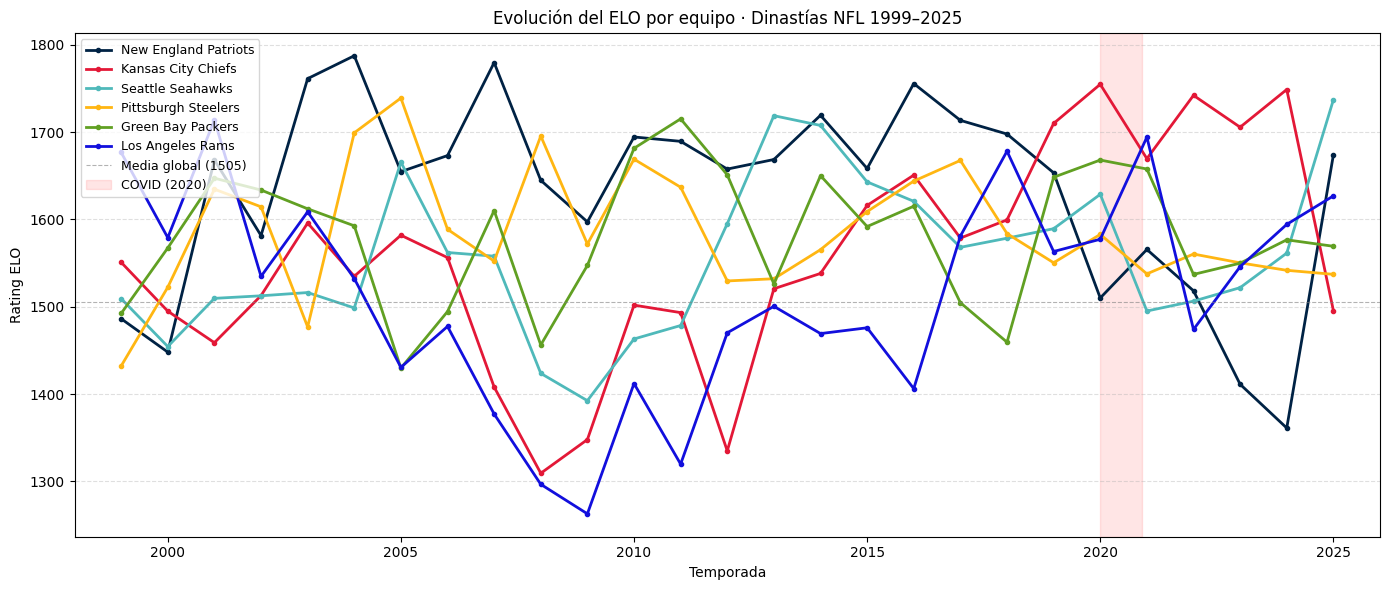

In [12]:
# Equipos con historia relevante 1999–2025
EQUIPOS = {
    'NE' : ('New England Patriots', '#002244'),
    'KC' : ('Kansas City Chiefs',   '#E31837'),
    'SEA': ('Seattle Seahawks',     "#4FB9BA"),
    'PIT': ('Pittsburgh Steelers',  '#FFB612'),
    'GB' : ('Green Bay Packers',    "#61A023"),
    'LA' : ('Los Angeles Rams',      "#120FDD")}

# ELO al cierre de cada temporada (último partido de cada equipo por season)
elo_season = (
    history_df
    .sort_values(['season', 'week'])
    .groupby(['season', 'home_team'])['elo_home_post']
    .last()
    .reset_index()
    .rename(columns={'home_team': 'team', 'elo_home_post': 'elo'})
)

# También capturar cuando son visitantes
elo_away = (
    history_df
    .sort_values(['season', 'week'])
    .groupby(['season', 'away_team'])['elo_away_post']
    .last()
    .reset_index()
    .rename(columns={'away_team': 'team', 'elo_away_post': 'elo'})
)

# Combinar y quedarse con el último valor por equipo/temporada
elo_all = pd.concat([elo_season, elo_away])
elo_season_final = (
    elo_all
    .sort_values('elo')
    .groupby(['season', 'team'])['elo']
    .last()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for team, (name, color) in EQUIPOS.items():
    data = elo_season_final[elo_season_final['team'] == team]
    ax.plot(data['season'], data['elo'],
            label=name, color=color, linewidth=2, marker='o', markersize=3)

ax.axhline(1505, color='gray', linestyle='--', linewidth=0.8,
           alpha=0.6, label='Media global (1505)')
ax.axvspan(2020, 2020.9, alpha=0.1, color='red', label='COVID (2020)')

ax.set_xlabel('Temporada')
ax.set_ylabel('Rating ELO')
ax.set_title('Evolución del ELO por equipo · Dinastías NFL 1999–2025')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(1998, 2026)

plt.tight_layout()
plt.show()

### Viz 2 · Rankings al cierre de 2025

Distribución de ratings al final de la última temporada disponible.
Los equipos sobre 1505 (línea de referencia) son considerados sobre
la media histórica de la liga.

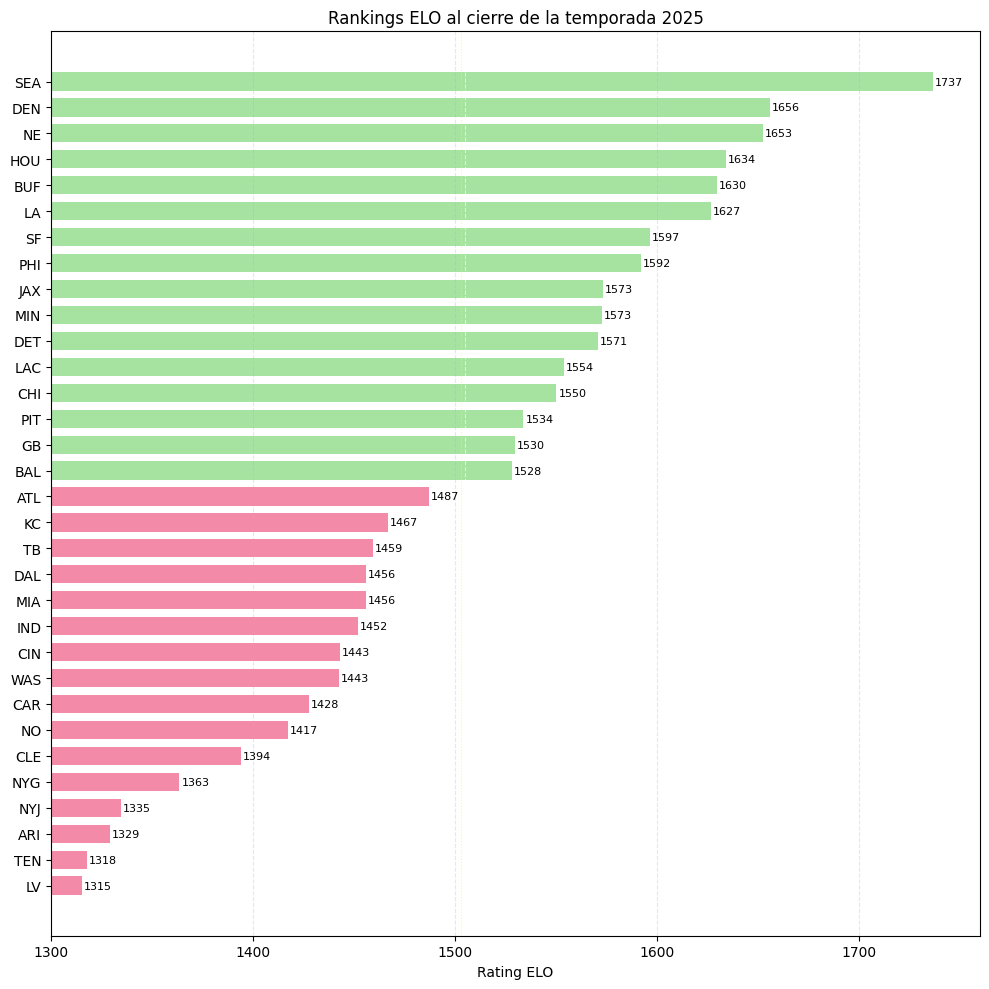

In [13]:
final_df = (
    pd.Series(final_elos)
    .reset_index()
    .rename(columns={'index': 'team', 0: 'elo'})
    .sort_values('elo', ascending=True)
)

colors = ['#a6e3a1' if e >= 1505 else '#f38ba8' for e in final_df['elo']]

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(final_df['team'], final_df['elo'], color=colors, height=0.7)
ax.axvline(1505, color='white', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(final_df['elo'].mean(), color='yellow',
           linestyle=':', linewidth=0.8, alpha=0.6)

# Etiquetas
for bar, val in zip(bars, final_df['elo']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

ax.set_xlabel('Rating ELO')
ax.set_title('Rankings ELO al cierre de la temporada 2025')
ax.set_xlim(1300, 1760)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Viz 3 · Calibration Curve

La calibration curve responde: *"cuando el modelo predice X%, ¿realmente
ocurre X% de las veces?"*

**Cómo leerla:**
- Puntos sobre la diagonal → modelo subestima (la realidad supera la predicción)
- Puntos bajo la diagonal → modelo sobreestima
- Diagonal perfecta → calibración ideal

Una desviación máxima de ~8 puntos porcentuales es aceptable. El modelo
logístico del Notebook 03 incorpora calibración implícita que debería
mejorar este resultado.

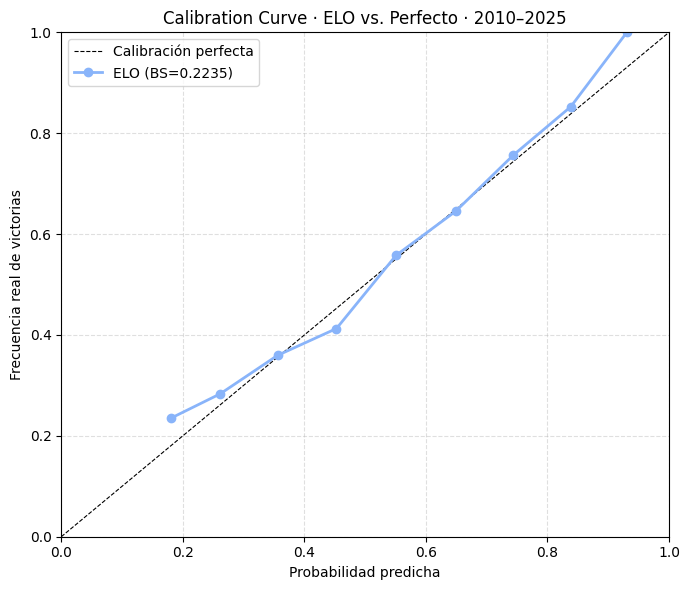

In [14]:
from sklearn.calibration import calibration_curve

bs_actual = np.mean((test['p_home'] - test['result']) ** 2)

# Usar período con Vegas para comparar ambas calibraciones
test = history_df[
    history_df['season'].isin(range(2010, 2026)) &
    history_df['game_type'].isin(['REG'])
].copy()

prob_true_elo, prob_pred_elo = calibration_curve(
    test['result'], test['p_home'], n_bins=10
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Calibración perfecta')
ax.plot(prob_pred_elo, prob_true_elo,
        'o-', color='#89b4fa', linewidth=2, markersize=6, label=f'ELO (BS={bs_actual:.4f})')

ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia real de victorias')
ax.set_title('Calibration Curve · ELO vs. Perfecto · 2010–2025')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Viz 4 · Distribución histórica de ratings

Verificamos que la distribución de ratings ELO a lo largo del tiempo sea
aproximadamente normal y centrada cerca de 1505.

Una distribución con cola derecha pronunciada indica que el sistema acumula
puntos en equipos dominantes — comportamiento esperado en una liga con
dinámicas de poder tan marcadas como la NFL.

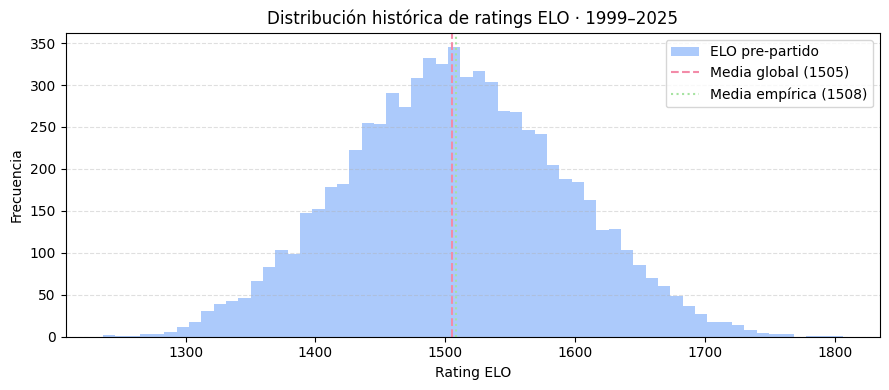

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(history_df['elo_home_pre'], bins=60,
        color='#89b4fa', alpha=0.7, label='ELO pre-partido')
ax.axvline(1505, color='#f38ba8', linestyle='--',
           linewidth=1.5, label='Media global (1505)')
ax.axvline(history_df['elo_home_pre'].mean(), color='#a6e3a1',
           linestyle=':', linewidth=1.5,
           label=f"Media empírica ({history_df['elo_home_pre'].mean():.0f})")

ax.set_xlabel('Rating ELO')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución histórica de ratings ELO · 1999–2025')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## §8 · Resumen y decisiones

### Parámetros confirmados

Todos los parámetros fueron derivados empíricamente desde los datos 1999–2025.

| Parámetro | Valor | Método de calibración |
|---|---|---|
| `HOME_ADVANTAGE` | 42.2 pts | Despeje algebraico desde home win rate observado 1999–2025 |
| `GLOBAL_MEAN` | 1503.1 | Media empírica de todos los ratings pre-partido |
| `K_REGULAR` | 40 | Grid search · validado out-of-sample 2020–2025 |
| `K_PLAYOFFS` | 48 | K × 1.2 sobre K_REGULAR calibrado |
| `REGRESSION_FACTOR` | 0.40 | Grid search · validado out-of-sample 2020–2025 |



> **Comparación vs. FiveThirtyEight:** HOME_ADVANTAGE=65, K=20, K_PLAYOFFS=24, alpha=0.33.
> Los valores difieren porque FiveThirtyEight calibró sobre datos 1920–2014.
> La NFL moderna (2010–2025) es más volátil por salary cap, libre agencia
> y mayor paridad — lo que justifica un K más alto y una regresión más agresiva.

---

### Resultados del backtesting

Evaluado sobre 4,175 juegos REG (2010–2025), mismo conjunto que el benchmark de Vegas.

| Métrica | Modelo nulo | ELO (FiveThirtyEight) | **ELO calibrado** | Vegas |
|---|---|---|---|---|
| Brier Score | 0.2500 | 0.2267 | **0.2235** | 0.2114 |
| Accuracy | ~56% | ~62% | **64.0%** | ~67% |
| Gap cerrado | 0% | 59.5% | **67.9%** | 100% |

La calibración de parámetros mejoró el Brier Score en **0.0032 puntos adicionales**
respecto a los parámetros de FiveThirtyEight, cerrando el gap contra Vegas
de 59.5% a 67.9%.

---

### Outputs generados

| Archivo | Contenido | Usado en |
|---|---|---|
| `data/processed/elo_history.csv` | ELO partido a partido 1999–2025 | Notebook 03 |
| `data/processed/elo_final_2025.csv` | Rating final por equipo al cierre de 2025 | Notebook 04 |

---

### Próximos pasos

El ELO calibrado cierra el **67.9% del gap** contra Vegas usando únicamente
el historial de resultados. El **Notebook 03** agrega features adicionales
mediante regresión logística para intentar cerrar parte del 32.1% restante:

| Feature | Hipótesis |
|---|---|
| `elo_diff` | Diferencia de calidad entre equipos · feature principal |
| `home_rest` | Más descanso → ventaja del local |
| `away_rest` | Más descanso → ventaja del visitante |
| `div_game` | Rivalidades divisionales reducen la ventaja del favorito |
| `week_norm` | Efecto de la semana normalizado por era (16 vs 17 juegos) |